In [1]:
import pandas as pd
import numpy as np
import csv
import glob
import os
import re
import matplotlib.pyplot as plt
import yaml
import pickle
%matplotlib inline

In [2]:
unc_folder = "/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis/"
conda_path = unc_folder + "conda/"
RMG_base_folder = unc_folder + "RMG-Py/"
RMG_db_folder = unc_folder + "RMG-database/"
conda_path = unc_folder + "conda/"
expt_yaml_file = ""
output_path  = "/scratch/blais.ch/methanol_results_2022_05_09/"

In [3]:
# we only want the ct_analysis files that were completed most recently, 
# which will have an objective function file with them
obj_func_filename = "objective_function_log2.txt"
# ct_filename = "ct_analysis_artol.csv"
ct_filename = "ct_analysis.csv"
ct_data_files = glob.glob(os.path.join(output_path,f"run_*/cantera/{ct_filename}"))

obj_func_files = [i.replace(ct_filename, obj_func_filename) for i in ct_data_files]

In [4]:
len(obj_func_files)

1417

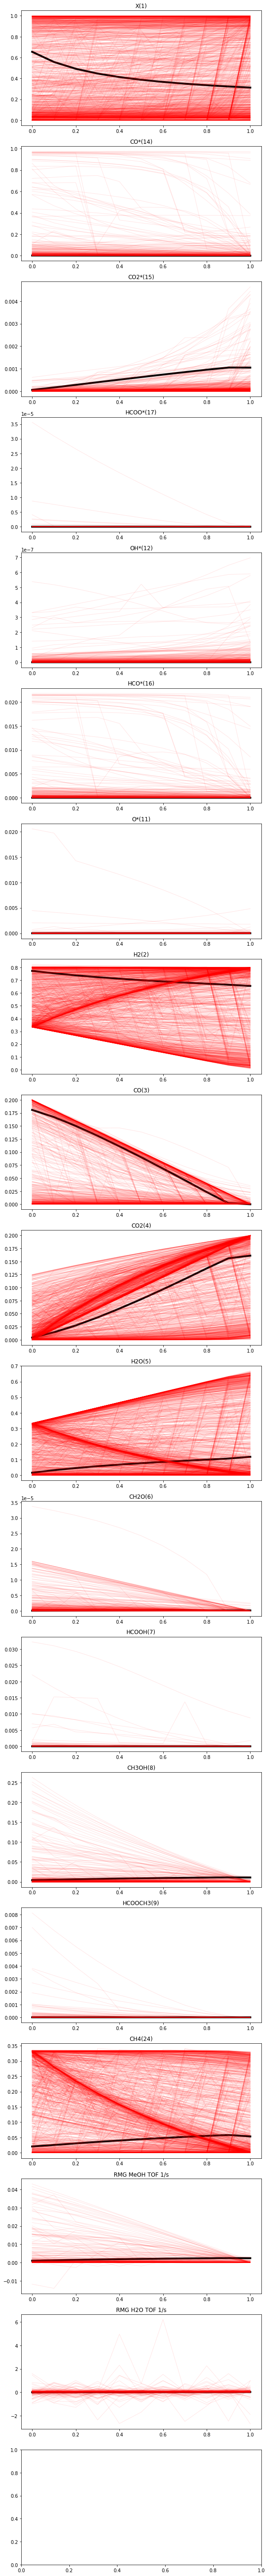

In [5]:
ct_data_dict = {}
model_size_dict = {}
pattern = re.compile('run_+\d')

# plt.rcParams['figure.figsize']=(1,1)

# things we want to plot
# first index is x-axis
data_keys = [
    "CO2/(CO2+CO)",
    "X(1)",
    "CO*(14)",
    "CO2*(15)",
    "HCOO*(17)",
    "OH*(12)",
    "HCO*(16)",
    "O*(11)",
    'H2(2)', 
    'CO(3)', 
    'CO2(4)',
    'H2O(5)', 
    'CH2O(6)', 
    'HCOOH(7)', 
    'CH3OH(8)', 
    'HCOOCH3(9)', 
    'CH4(24)',
    "RMG MeOH TOF 1/s",
    "RMG H2O TOF 1/s",
]

fig, axs = plt.subplots(nrows=len(data_keys), figsize=(8, 4 * len(data_keys)), tight_layout=True)
# fig.subplots_adjust(hspace=0.5, wspace=0.5)

for file in ct_data_files:
    
    # find the string for the run number 
    pattern = re.compile('run_\d{4}')
    match = re.search('run_\d{4}',file)
    run_num = int(match.group(0).replace('run_', ""))
    
    df = pd.read_csv(file)
    data_run = df[(df['Unnamed: 0'] >= 216) & (df['Unnamed: 0'] <= 226)]

#     ct_data_dict[run_num] = list(data_run["X(1)"])

    data_dict = {}
    
    # label best fit model with a black line
    if run_num == 3171:
        color = "k"
        alpha = 1.0
        linewidth=4
    else:
        color = "r"
        alpha = 0.1
        linewidth=1
    
    for key in data_keys:   
        data_dict[key] = list(data_run[key]) 
            
    for index, key in enumerate(data_keys):
        if index != 0:   
            data_dict[key] = list(data_run[key]) 
            axs[index-1].plot(
                data_dict[data_keys[0]], 
                data_dict[key], 
                color=color, 
                linewidth=linewidth, 
                alpha=alpha
            )
            
            axs[index-1].set_title(key)

## make activity maps for meoh and water
plot BE vs meoh TOF
- H vs C
- H vs O
- H vs vdw
- C vs O
- C vs vdw
- O vs vdw

In [56]:
# we only want the ct_analysis files that were completed most recently, 
# which will have an objective function file with them
obj_func_filename = "objective_function_log2.txt"
# ct_filename = "ct_analysis_artol.csv"
ct_filename = "ct_analysis.csv"
ct_data_files = glob.glob(os.path.join(output_path,f"run_*/cantera/{ct_filename}"))

obj_func_files = [i.replace(ct_filename, obj_func_filename) for i in ct_data_files]

In [57]:
for file in ct_data_files:
    if str(3171) in file:
        best_fit_model = file
        print(file)
        break

/scratch/blais.ch/methanol_results_2022_05_09/run_3171/cantera/ct_analysis.csv


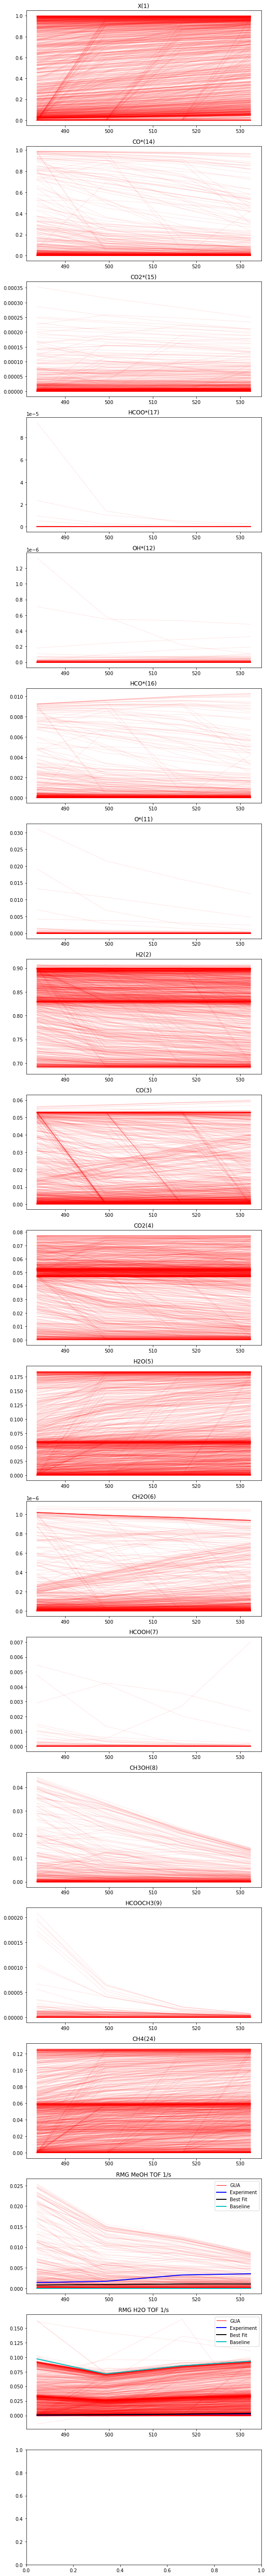

In [64]:
ct_data_dict = {}
model_size_dict = {}
pattern = re.compile('run_+\d')

# plt.rcParams['figure.figsize']=(1,1)

# things we want to plot
# first index is x-axis
data_keys = [
#     "CO2/(CO2+CO)",
    "T (K)",
    "X(1)",
    "CO*(14)",
    "CO2*(15)",
    "HCOO*(17)",
    "OH*(12)",
    "HCO*(16)",
    "O*(11)",
    'H2(2)', 
    'CO(3)', 
    'CO2(4)',
    'H2O(5)', 
    'CH2O(6)', 
    'HCOOH(7)', 
    'CH3OH(8)', 
    'HCOOCH3(9)', 
    'CH4(24)',
    "RMG MeOH TOF 1/s",
    "RMG H2O TOF 1/s",
]

fig, axs = plt.subplots(nrows=len(data_keys), figsize=(8, 4 * len(data_keys)), tight_layout=True)
fig.subplots_adjust(hspace=0.0, wspace=0.0)

first_run = True
for file in ct_data_files:

    # find the string for the run number 
    pattern = re.compile('run_\d{4}')
    match = re.search('run_\d{4}',file)
    run_num = int(match.group(0).replace('run_', ""))
    
    df = pd.read_csv(file)
    data_run = df[(df['Unnamed: 0'] == 30) | (df['Unnamed: 0'] == 36) |(df['Unnamed: 0'] == 48)|(df['Unnamed: 0'] == 42)]

    data_dict = {}
    color = "r"
    alpha = 0.1
    linewidth=1
    zorder=0
    
    for key in data_keys:   
        data_dict[key] = list(data_run[key]) 
            
    for index, key in enumerate(data_keys):
        if index != 0:   
            data_dict[key] = list(data_run[key])
            if first_run:
                axs[index-1].plot(
                    data_dict[data_keys[0]], 
                    data_dict[key], 
                    color=color, 
                    linewidth=linewidth, 
                    alpha=alpha,
                    label="GUA",
                    zorder=zorder
                )
            else:
                axs[index-1].plot(
                    data_dict[data_keys[0]], 
                    data_dict[key], 
                    color=color, 
                    linewidth=linewidth, 
                    alpha=alpha,
                    label="_GUA",
                    zorder=zorder
                )
#             if key == "RMG H2O TOF 1/s" or key =="RMG MeOH TOF 1/s": 
# #                 axs[index-1].set_ylim(1e-1,0.005)
#                 axs[index-1].set_yscale("log")
            axs[index-1].set_title(key)
    first_run = False
    
# plot graaf data
axs[-3].plot(
    data_dict[data_keys[0]], 
    list(data_run["graaf MeOH TOF 1/s"]), 
    color="b", 
    linewidth=2.0, 
    alpha=1.0,
    label="Experiment",
    zorder=2
)

axs[-2].plot(
    data_dict[data_keys[0]], 
    list(data_run["graaf H2O TOF 1/s"]), 
    color="b", 
    linewidth=2.0, 
    alpha=1.0,
    label="Experiment",
    zorder=2
)

# plot best fit
df = pd.read_csv(best_fit_model)
data_run = df[(df['Unnamed: 0'] == 30) | (df['Unnamed: 0'] == 36) |(df['Unnamed: 0'] == 48)|(df['Unnamed: 0'] == 42)]

axs[-3].plot(
    list(data_run["T (K)"]), 
    list(data_run["RMG MeOH TOF 1/s"]), 
    color="k", 
    linewidth=2.0, 
    alpha=1.0,
    label="Best Fit",
    zorder=4
)

axs[-2].plot(
    list(data_run["T (K)"]), 
    list(data_run["RMG H2O TOF 1/s"]), 
    color="k", 
    linewidth=2.0, 
    alpha=1.0,
    label="Best Fit",
    zorder=4
)

# plot baseline data
df = pd.read_csv("/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis/uncertainty_baseline/cantera/ct_analysis.csv")
data_run = df[(df['Unnamed: 0'] == 30) | (df['Unnamed: 0'] == 36) |(df['Unnamed: 0'] == 48)|(df['Unnamed: 0'] == 42)]

axs[-3].plot(
    list(data_run["T (K)"]), 
    list(data_run["RMG MeOH TOF 1/s"]), 
    color="c", 
    linewidth=2.0, 
    alpha=1.0,
    label="Baseline",
    zorder=3
)

axs[-2].plot(
    list(data_run["T (K)"]), 
    list(data_run["RMG H2O TOF 1/s"]), 
    color="c", 
    linewidth=2.0, 
    alpha=1.0,
    label="Baseline",
    zorder=3
)
axs[-2].legend()
axs[-3].legend()

leg = axs[-2].legend()
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    
leg = axs[-3].legend()
for lh in leg.legendHandles: 
    lh.set_alpha(1)

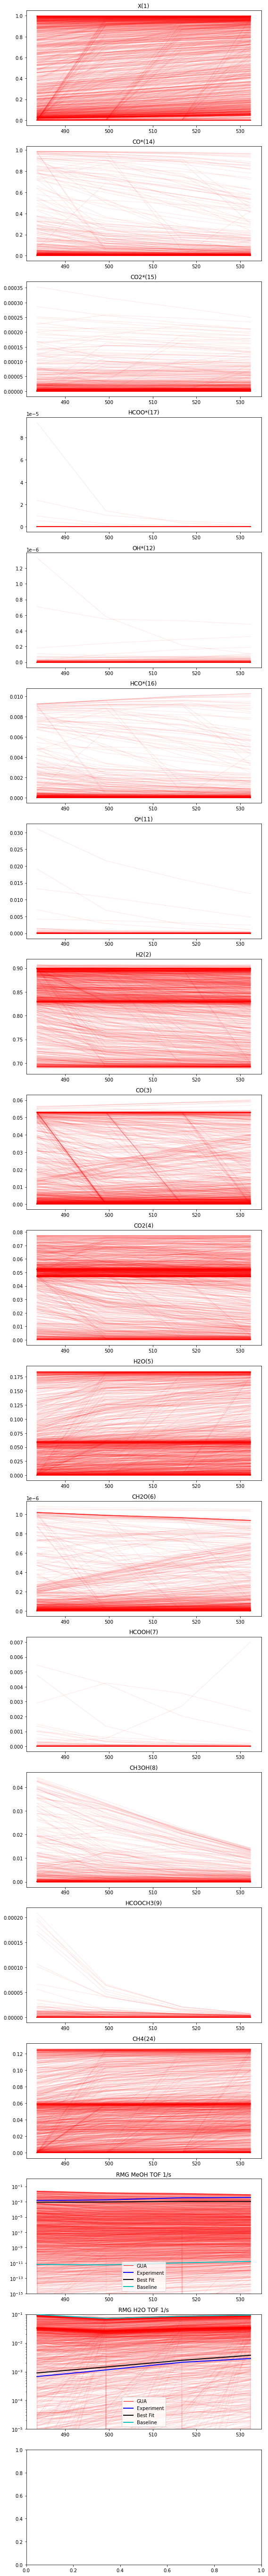

In [63]:
ct_data_dict = {}
model_size_dict = {}
pattern = re.compile('run_+\d')

# plt.rcParams['figure.figsize']=(1,1)

# things we want to plot
# first index is x-axis
data_keys = [
#     "CO2/(CO2+CO)",
    "T (K)",
    "X(1)",
    "CO*(14)",
    "CO2*(15)",
    "HCOO*(17)",
    "OH*(12)",
    "HCO*(16)",
    "O*(11)",
    'H2(2)', 
    'CO(3)', 
    'CO2(4)',
    'H2O(5)', 
    'CH2O(6)', 
    'HCOOH(7)', 
    'CH3OH(8)', 
    'HCOOCH3(9)', 
    'CH4(24)',
    "RMG MeOH TOF 1/s",
    "RMG H2O TOF 1/s",
]

fig, axs = plt.subplots(nrows=len(data_keys), figsize=(8, 4 * len(data_keys)), tight_layout=True)
fig.subplots_adjust(hspace=0.0, wspace=0.0)

first_run = True
for file in ct_data_files:

    # find the string for the run number 
    pattern = re.compile('run_\d{4}')
    match = re.search('run_\d{4}',file)
    run_num = int(match.group(0).replace('run_', ""))
    
    df = pd.read_csv(file)
    data_run = df[(df['Unnamed: 0'] == 30) | (df['Unnamed: 0'] == 36) |(df['Unnamed: 0'] == 48)|(df['Unnamed: 0'] == 42)]

    data_dict = {}
    color = "r"
    alpha = 0.1
    linewidth=1
    zorder=0
    
    for key in data_keys:   
        data_dict[key] = list(data_run[key]) 
            
    for index, key in enumerate(data_keys):
        if index != 0:   
            data_dict[key] = list(data_run[key])
            if first_run:
                axs[index-1].plot(
                    data_dict[data_keys[0]], 
                    data_dict[key], 
                    color=color, 
                    linewidth=linewidth, 
                    alpha=alpha,
                    label="GUA",
                    zorder=zorder
                )
            else:
                axs[index-1].plot(
                    data_dict[data_keys[0]], 
                    data_dict[key], 
                    color=color, 
                    linewidth=linewidth, 
                    alpha=alpha,
                    label="_GUA",
                    zorder=zorder
                )
            axs[index-1].set_title(key)
    first_run = False
    
# plot graaf data
axs[-3].plot(
    data_dict[data_keys[0]], 
    list(data_run["graaf MeOH TOF 1/s"]), 
    color="b", 
    linewidth=2.0, 
    alpha=1.0,
    label="Experiment",
    zorder=2
)

axs[-2].plot(
    data_dict[data_keys[0]], 
    list(data_run["graaf H2O TOF 1/s"]), 
    color="b", 
    linewidth=2.0, 
    alpha=1.0,
    label="Experiment",
    zorder=2
)

# plot best fit
df = pd.read_csv(best_fit_model)
data_run = df[(df['Unnamed: 0'] == 30) | (df['Unnamed: 0'] == 36) |(df['Unnamed: 0'] == 48)|(df['Unnamed: 0'] == 42)]

axs[-3].plot(
    list(data_run["T (K)"]), 
    list(data_run["RMG MeOH TOF 1/s"]), 
    color="k", 
    linewidth=2.0, 
    alpha=1.0,
    label="Best Fit",
    zorder=4
)

axs[-2].plot(
    list(data_run["T (K)"]), 
    list(data_run["RMG H2O TOF 1/s"]), 
    color="k", 
    linewidth=2.0, 
    alpha=1.0,
    label="Best Fit",
    zorder=4
)

# plot baseline data
df = pd.read_csv("/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis/uncertainty_baseline/cantera/ct_analysis.csv")
data_run = df[(df['Unnamed: 0'] == 30) | (df['Unnamed: 0'] == 36) |(df['Unnamed: 0'] == 48)|(df['Unnamed: 0'] == 42)]

axs[-3].plot(
    list(data_run["T (K)"]), 
    list(data_run["RMG MeOH TOF 1/s"]), 
    color="c", 
    linewidth=2.0, 
    alpha=1.0,
    label="Baseline",
    zorder=3
)

axs[-2].plot(
    list(data_run["T (K)"]), 
    list(data_run["RMG H2O TOF 1/s"]), 
    color="c", 
    linewidth=2.0, 
    alpha=1.0,
    label="Baseline",
    zorder=3
)
axs[-2].legend()
axs[-3].legend()


axs[-2].set_ylim(1e-5,1e-1)
axs[-2].set_yscale("log")

axs[-3].set_ylim(1e-15,1)
axs[-3].set_yscale("log")

leg = axs[-2].legend()
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    
leg = axs[-3].legend()
for lh in leg.legendHandles: 
    lh.set_alpha(1)

In [23]:
data_run["RMG MeOH TOF 1/s"]

30    0.097014
36    0.071296
42    0.085235
48    0.092959
Name: RMG H2O TOF 1/s, dtype: float64

In [8]:
df[(df['Unnamed: 0'] == 29) | (df['Unnamed: 0'] == 36) |(df['Unnamed: 0'] == 48)|(df['Unnamed: 0'] == 42)]

,Unnamed: 0,experiment,use_for_opt,time (s),T (K),P (Pa),V (m^3/s),x_CO initial,x_CO2 initial,x_H2 initial,...,C2HOX(199) + SX(122) <=> SX(114) + SX(166) ROP [kmol/m^2 s],C2HOX(199) + SX(122) <=> SX(166) + SX(188) ROP [kmol/m^2 s],C2HOX(199) + SX(122) <=> SX(132) + SX(166) ROP [kmol/m^2 s],CO(3) + H2(2) <=> CH2O(6) ROP [kmol/m^3 s],CO(3) + H2O(5) <=> HCOOH(7) ROP [kmol/m^3 s],CO2(4) + H2(2) <=> HCOOH(7) ROP [kmol/m^3 s],CH3OH(8) + CO(3) <=> HCOOCH3(9) ROP [kmol/m^3 s],CH4(24) + CO2(4) <=> HCOOCH3(9) ROP [kmol/m^3 s],CH4(24) + CO2(4) <=> C2H4O2(73) ROP [kmol/m^3 s],C2H2O(126) + H2O(5) <=> C2H4O2(73) ROP [kmol/m^3 s]
29,29,graaf_1988,True,3384.683421,483.5,1.510000e+06,0.000010,0.053,0.047,0.9,...,1.792534e-45,8.920861e-42,2.773412e-47,6.674153e-37,-2.731400e-25,5.564614e-31,-5.020395e-31,-1.462114e-24,-1.120621e-31,8.781857e-26
36,36,graaf_1988,True,2316.806227,499.3,1.500000e+06,0.000015,0.053,0.047,0.9,...,1.086102e-44,4.225661e-41,1.976763e-46,1.141333e-35,-2.514262e-24,9.185932e-30,-3.879541e-30,-8.386051e-24,-7.869107e-31,4.532595e-25
42,42,graaf_1988,True,1538.883116,516.7,1.510000e+06,0.000018,0.053,0.047,0.9,...,2.440972e-44,7.373933e-41,5.201342e-46,1.636331e-34,-1.990933e-23,1.323069e-28,-1.526643e-29,-2.750781e-23,-1.782052e-30,1.691120e-24
48,48,graaf_1988,False,13.807810,532.4,1.510000e+06,0.000020,0.053,0.047,0.9,...,4.700934e-44,1.147709e-40,1.137956e-45,1.501390e-33,-1.197779e-22,1.223838e-27,-3.276617e-29,-6.705815e-23,1.010325e-29,5.026237e-24


In [9]:
for file in ct_data_files:
    
    # find the string for the run number 
    pattern = re.compile('run_\d{4}')
    match = re.search('run_\d{4}',file)
    run_num = int(match.group(0).replace('run_', ""))
    
    df = pd.read_csv(file)
    data_run = df[(df['Unnamed: 0'] <= 226) & (df['Unnamed: 0'] >= 216)]
    

In [10]:
df = pd.read_csv(file)
data_run = df[(df['Unnamed: 0'] <= 120) & (df['Unnamed: 0'] >= 100)]
data_run

,Unnamed: 0,experiment,use_for_opt,time (s),T (K),P (Pa),V (m^3/s),x_CO initial,x_CO2 initial,x_H2 initial,...,C2HOX(199) + SX(122) <=> SX(114) + SX(166) ROP [kmol/m^2 s],C2HOX(199) + SX(122) <=> SX(166) + SX(188) ROP [kmol/m^2 s],C2HOX(199) + SX(122) <=> SX(132) + SX(166) ROP [kmol/m^2 s],CO(3) + H2(2) <=> CH2O(6) ROP [kmol/m^3 s],CO(3) + H2O(5) <=> HCOOH(7) ROP [kmol/m^3 s],CO2(4) + H2(2) <=> HCOOH(7) ROP [kmol/m^3 s],CH3OH(8) + CO(3) <=> HCOOCH3(9) ROP [kmol/m^3 s],CH4(24) + CO2(4) <=> HCOOCH3(9) ROP [kmol/m^3 s],CH4(24) + CO2(4) <=> C2H4O2(73) ROP [kmol/m^3 s],C2H2O(126) + H2O(5) <=> C2H4O2(73) ROP [kmol/m^3 s]
100,100,graaf_1988,True,2428.339345,516.7,1.500000e+06,0.000015,0.120,0.021,0.859,...,8.391645e-44,2.534980e-40,1.780659e-45,1.821274e-34,-1.071731e-23,4.764195e-29,-2.239272e-29,-4.284102e-23,-5.357672e-30,4.225621e-24
101,101,graaf_1988,True,101.308057,516.7,3.000000e+06,0.000009,0.120,0.021,0.859,...,2.353209e-46,7.098379e-43,4.591245e-48,7.917819e-35,-3.868759e-24,2.886157e-29,-2.098131e-30,-3.302288e-24,2.318498e-30,7.800464e-25
102,102,graaf_1988,True,55.700314,516.7,2.970000e+06,0.000016,0.120,0.021,0.859,...,4.273774e-45,1.288243e-41,8.729089e-47,1.675268e-34,-7.897679e-24,5.255638e-29,-9.430213e-30,-1.487164e-23,3.287907e-30,2.521137e-24
103,103,graaf_1988,True,136.272535,516.7,5.000000e+06,0.000011,0.120,0.021,0.859,...,6.112590e-47,1.842880e-43,1.161047e-48,9.316268e-35,-4.568470e-24,3.664697e-29,-1.593812e-30,-2.259916e-24,2.637228e-30,7.133173e-25
104,104,graaf_1988,True,84.339484,516.7,4.980000e+06,0.000017,0.120,0.021,0.859,...,6.124583e-46,1.844998e-42,1.213244e-47,1.704714e-34,-7.737591e-24,5.921076e-29,-5.358699e-30,-7.602720e-24,4.207906e-30,1.866899e-24
105,105,graaf_1988,False,2503.986900,532.4,1.500000e+06,0.000011,0.120,0.021,0.859,...,2.455667e-44,6.002748e-41,5.745531e-46,9.998608e-34,-3.195225e-23,2.883151e-28,-1.602613e-29,-3.818266e-23,1.665279e-29,5.767318e-24
106,106,graaf_1988,False,2241.126184,532.4,1.500000e+06,0.000019,0.120,0.021,0.859,...,2.983125e-43,7.283985e-40,7.232132e-45,1.934811e-33,-6.544679e-23,4.942377e-28,-5.919636e-29,-1.406806e-22,-7.964154e-30,1.577038e-23
107,107,graaf_1988,False,80.927969,532.4,2.990000e+06,0.000011,0.120,0.021,0.859,...,1.049024e-45,2.558119e-42,2.320842e-47,8.610598e-34,-2.696232e-23,2.926267e-28,-7.378008e-30,-1.121632e-23,2.322057e-29,2.775288e-24
108,108,graaf_1988,False,46.911563,532.4,2.980000e+06,0.000018,0.120,0.021,0.859,...,1.226671e-44,2.986803e-41,2.844592e-46,1.676175e-33,-4.967298e-23,5.065747e-28,-2.797542e-29,-4.257549e-23,3.710227e-29,8.018085e-24
109,109,graaf_1988,False,136.896298,532.4,4.980000e+06,0.000010,0.120,0.021,0.859,...,1.125992e-46,2.748172e-43,2.369023e-48,7.801646e-34,-2.559593e-23,2.951487e-28,-3.697572e-30,-4.583724e-24,2.038043e-29,1.590563e-24
